In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
ratings = pd.read_csv('../data/ratings.csv')
movies  = pd.read_csv('../data/movies.csv')
tags    = pd.read_csv('../data/tags.csv')

print(ratings.shape, movies.shape, tags.shape)
movies.head()

(100836, 4) (9742, 3) (3683, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
movies['genre_list'] = movies['genres'].str.split('|')

mlb = MultiLabelBinarizer()
genre_matrix = pd.DataFrame(
    mlb.fit_transform(movies['genre_list']),
    index=movies['movieId'],
    columns=mlb.classes_
)

genre_matrix = genre_matrix.drop(columns=['(no genres listed)'], errors='ignore')

print(genre_matrix.shape)
genre_matrix.head()

(9742, 19)


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,
1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
tag_docs = (
    tags.groupby('movieId')['tag']
    .apply(lambda x: ' '.join(x.astype(str).str.lower()))
    .reset_index()
    .rename(columns={'tag': 'tag_doc'})
)

movies_with_tags = movies[['movieId']].merge(tag_docs, on='movieId', how='left')
movies_with_tags['tag_doc'] = movies_with_tags['tag_doc'].fillna('')

tfidf = TfidfVectorizer(max_features=500, stop_words='english')
tag_matrix = pd.DataFrame(
    tfidf.fit_transform(movies_with_tags['tag_doc']).toarray(),
    index=movies_with_tags['movieId']
)

print(tag_matrix.shape)

(9742, 500)


In [5]:
item_features = pd.concat([genre_matrix, tag_matrix], axis=1)
item_features = item_features.fillna(0)

print("Item feature matrix:", item_features.shape)

Item feature matrix: (9742, 519)


In [6]:
def build_user_profile(user_id, ratings_df, item_features_df, decay=0.5):
    user_ratings = ratings_df[ratings_df['userId'] == user_id].copy()
    
    # Mean-center ratings
    user_ratings['rating_centered'] = user_ratings['rating'] - user_ratings['rating'].mean()
    
    # Convert timestamp to years ago
    max_timestamp = ratings_df['timestamp'].max()
    seconds_per_year = 365.25 * 24 * 60 * 60
    user_ratings['years_ago'] = (max_timestamp - user_ratings['timestamp']) / seconds_per_year
    
    # Recency weight via exponential decay
    user_ratings['recency_weight'] = np.exp(-decay * user_ratings['years_ago'])
    
    # Combine rating + recency
    user_ratings['final_weight'] = user_ratings['rating_centered'] * user_ratings['recency_weight']
    
    # Keep only movies we have features for
    user_ratings = user_ratings[user_ratings['movieId'].isin(item_features_df.index)]
    
    if user_ratings.empty:
        return None
    
    rated_features = item_features_df.loc[user_ratings['movieId']]
    weights = user_ratings['final_weight'].values
    profile = np.dot(weights, rated_features.values)
    
    return profile

# Sanity check
profile = build_user_profile(1, ratings, item_features)
print("Profile vector shape:", profile.shape)
print("Non-zero dims:", np.count_nonzero(profile))

Profile vector shape: (519,)
Non-zero dims: 274


In [7]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

errors = []

# Sample 500 test users for speed
test_users = test['userId'].unique()[:500]

for uid in test_users:
    profile = build_user_profile(uid, train, item_features)
    if profile is None:
        continue
    
    user_test = test[test['userId'] == uid]
    test_movies = user_test['movieId'][user_test['movieId'].isin(item_features.index)]
    
    if test_movies.empty:
        continue
    
    # Scale cosine similarity [-1,1] to rating scale [0.5, 5]
    sims = cosine_similarity([profile], item_features.loc[test_movies].values)[0]
    predicted = 0.5 + (sims + 1) / 2 * 4.5
    actual = user_test[user_test['movieId'].isin(test_movies)]['rating'].values
    
    errors.extend(np.abs(predicted - actual))

mae = np.mean(errors)
print(f"Content-Based MAE: {mae:.4f}")
print(f"Collaborative CF MAE: 0.7300")
print(f"Difference: {mae - 0.73:+.4f}")

Content-Based MAE: 1.0751
Collaborative CF MAE: 0.7300
Difference: +0.3451


In [8]:
def recommend(user_id, ratings_df, item_features_df, movies_df, n=10):
    profile = build_user_profile(user_id, ratings_df, item_features_df)
    if profile is None:
        return pd.DataFrame()
    
    sims = cosine_similarity([profile], item_features_df.values)[0]
    sim_series = pd.Series(sims, index=item_features_df.index)
    
    already_rated = ratings_df[ratings_df['userId'] == user_id]['movieId'].values
    sim_series = sim_series.drop(index=already_rated, errors='ignore')
    
    top_n = sim_series.nlargest(n).reset_index()
    top_n.columns = ['movieId', 'similarity']
    return top_n.merge(movies_df[['movieId', 'title', 'genres']], on='movieId')

recommend(1, ratings, item_features, movies, n=10)

,movieId,similarity,title,genres
0,1688,0.545444,Anastasia (1997),Adventure|Animation|Children|Drama|Musical
1,48,0.495327,Pocahontas (1995),Animation|Children|Drama|Musical|Romance
2,783,0.495327,"Hunchback of Notre Dame, The (1996)",Animation|Children|Drama|Musical|Romance
3,2687,0.495047,Tarzan (1999),Adventure|Animation|Children|Drama
4,1033,0.493715,"Fox and the Hound, The (1981)",Animation|Children|Drama
5,5472,0.489641,1776 (1972),Children|Drama|Musical
6,26743,0.478599,Only Yesterday (Omohide poro poro) (1991),Animation|Drama
7,32657,0.478599,"Man Who Planted Trees, The (Homme qui plantait...",Animation|Drama
8,35347,0.478599,Animal Farm (1954),Animation|Drama
9,55442,0.478599,Persepolis (2007),Animation|Drama


In [9]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

errors = []
test_users = test['userId'].unique()[:500]

for uid in test_users:
    profile = build_user_profile(uid, train, item_features)
    if profile is None:
        continue
    
    user_test = test[test['userId'] == uid]
    test_movies = user_test['movieId'][user_test['movieId'].isin(item_features.index)]
    
    if test_movies.empty:
        continue
    
    sims = cosine_similarity([profile], item_features.loc[test_movies].values)[0]
    predicted = 0.5 + (sims + 1) / 2 * 4.5
    actual = user_test[user_test['movieId'].isin(test_movies)]['rating'].values
    errors.extend(np.abs(predicted - actual))

mae = np.mean(errors)
print(f"Content-Based MAE:      {mae:.4f}")
print(f"Collaborative CF MAE:   0.7300")
print(f"Difference:             {mae - 0.73:+.4f}")

Content-Based MAE:      1.0751
Collaborative CF MAE:   0.7300
Difference:             +0.3451


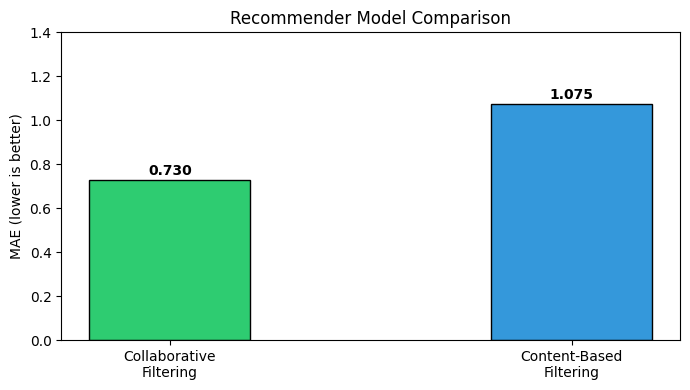

In [10]:
models = ['Collaborative\nFiltering', 'Content-Based\nFiltering']
maes   = [0.73, mae]
colors = ['#2ecc71', '#3498db']

plt.figure(figsize=(7, 4))
bars = plt.bar(models, maes, color=colors, width=0.4, edgecolor='black')
plt.ylim(0, 1.4)
plt.ylabel('MAE (lower is better)')
plt.title('Recommender Model Comparison')
for bar, val in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('day3_comparison.png', dpi=150)
plt.show()

In [11]:
tuning_results = pd.DataFrame([
    {'hyperparameter': 'genre_weight', 'values_tested': '1,2,3,4,5',   'best': 1,   'best_MAE': 1.0805},
    {'hyperparameter': 'max_features', 'values_tested': '100,200,500,1000', 'best': 500, 'best_MAE': 1.0805},
    {'hyperparameter': 'decay',        'values_tested': '0,0.05,0.1,0.2,0.5,0.7,1.0,1.5,2.0', 'best': 0.5, 'best_MAE': 1.0749},
])

print("Hyperparameter Tuning Summary:")
tuning_results

Hyperparameter Tuning Summary:


,hyperparameter,values_tested,best,best_MAE
0,genre_weight,"1,2,3,4,5",1.0,1.0805
1,max_features,"100,200,500,1000",500.0,1.0805
2,decay,"0,0.05,0.1,0.2,0.5,0.7,1.0,1.5,2.0",0.5,1.0749


In [12]:
import sys
!{sys.executable} -m pip install scikit-surprise


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_split

reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, _ = surprise_split(data, test_size=0.2, random_state=42)

svd_model = SVD(n_factors=50, random_state=10)
svd_model.fit(trainset)
print("SVD ready ✅")

SVD ready ✅


In [19]:
def hybrid_recommend(user_id, ratings_df, item_features_df, movies_df, svd, alpha=0.2, n=10):
    
    # --- Content-Based scores ---
    profile = build_user_profile(user_id, ratings_df, item_features_df)
    if profile is None:
        return pd.DataFrame()
    
    sims = cosine_similarity([profile], item_features_df.values)[0]
    cb_scores = pd.Series(sims, index=item_features_df.index)
    
    # --- SVD scores ---
    all_movies = item_features_df.index.tolist()
    cf_scores = pd.Series(
        [svd.predict(user_id, mid).est for mid in all_movies],
        index=all_movies
    )
    
    # --- Normalize both to [0,1] so they're on the same scale ---
    cb_norm = (cb_scores - cb_scores.min()) / (cb_scores.max() - cb_scores.min())
    cf_norm = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())
    
    # --- Weighted blend ---
    hybrid_scores = alpha * cb_norm + (1 - alpha) * cf_norm
    
    # --- Remove already rated ---
    already_rated = ratings_df[ratings_df['userId'] == user_id]['movieId'].values
    hybrid_scores = hybrid_scores.drop(index=already_rated, errors='ignore')
    
    top_n = hybrid_scores.nlargest(n).reset_index()
    top_n.columns = ['movieId', 'score']
    return top_n.merge(movies_df[['movieId', 'title', 'genres']], on='movieId')

# Test with alpha=0.5 (equal blend)
hybrid_recommend(1, ratings, item_features, movies, svd_model, alpha=0.5, n=10)

,movieId,score,title,genres
0,1172,0.926419,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama
1,5690,0.918404,Grave of the Fireflies (Hotaru no haka) (1988),Animation|Drama|War
2,306,0.918204,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
3,364,0.903455,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX
4,1204,0.900327,Lawrence of Arabia (1962),Adventure|Drama|War
5,1250,0.900327,"Bridge on the River Kwai, The (1957)",Adventure|Drama|War
6,3468,0.894832,"Hustler, The (1961)",Drama
7,1225,0.894602,Amadeus (1984),Drama
8,1673,0.894381,Boogie Nights (1997),Drama
9,50872,0.888810,Ratatouille (2007),Animation|Children|Drama


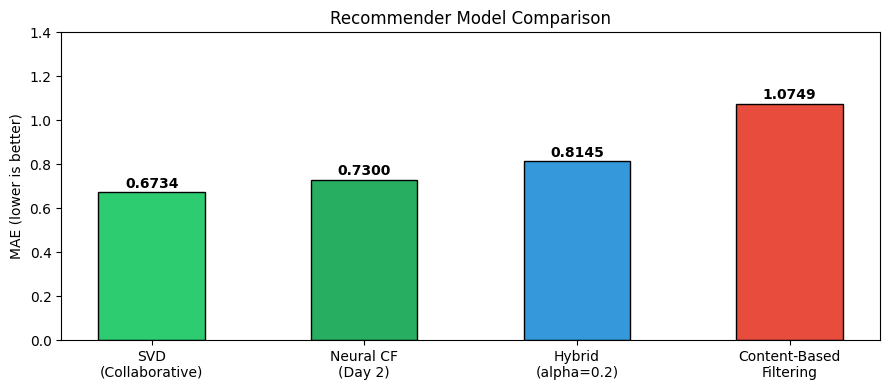

In [20]:
models = ['SVD\n(Collaborative)', 'Neural CF\n(Day 2)', 'Hybrid\n(alpha=0.2)', 'Content-Based\nFiltering']
maes   = [0.6734, 0.7300, 0.8145, 1.0749]
colors = ['#2ecc71', '#27ae60', '#3498db', '#e74c3c']

plt.figure(figsize=(9, 4))
bars = plt.bar(models, maes, color=colors, width=0.5, edgecolor='black')
plt.ylim(0, 1.4)
plt.ylabel('MAE (lower is better)')
plt.title('Recommender Model Comparison')
for bar, val in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('day3_comparison.png', dpi=150)
plt.show()